# Validación Interna TSTR — HybridConv1DAutoencoder — SWaT A12 (Marzo 2026)

## Correcciones respecto a la versión anterior del TSTR

El notebook anterior (versión A7) usaba un `Conv1dAutoencoder` simplificado que
tenía dos problemas arquitecturales críticos:

| Problema | Versión anterior | Esta versión |
|----------|-----------------|--------------|
| **Arquitectura** | `Conv1dAutoencoder` genérico (14K params) | `HybridConv1DAutoencoder` de 01b (163K params, diseñado por Optuna) |
| **Discretas** | Resumen estadístico → concatenar → Conv1D (incoherente) | Resumen estadístico → rama MLP independiente (correcto) |
| **Parámetros** | 14,606 | 163,807 (11x más capacidad) |
| **Hiperparámetros** | Genéricos | Los mismos de 01b (Optuna los optimizó para A12) |
| **Alpha** | Fijo en 0.5 | **0.306** (valor óptimo de Optuna) |

### Por qué el modelo híbrido es la arquitectura correcta

El `HybridConv1DAutoencoder` separa correctamente las dos naturalezas de las variables:

- **Continuas** → rama Conv1D: extrae patrones temporales en series como LIT101, AIT201, PIT501
- **Discretas (resumen estadístico)** → rama MLP: no hay temporalidad en la moda de MV101 o en el número de transiciones de P3_STATE — tratarlos con Conv1D era semánticamente incorrecto

La fusión en el bottleneck combina ambas representaciones y las reconstituye por separado.
El score de anomalía es `alpha*MSE_cont + (1-alpha)*MSE_disc`, igual que en 01b.

### Datos sintéticos — formato correcto

- `synth_for_detector.npy`: continuas ya escaladas (N, 30, 31) → transponer → (N, 31, 30) para la rama Conv1D
- `synth_disc_raw.npy`: discretas en escala original (N, 30, 31) → summarize → (N, 124) para la rama MLP


## 0. Imports

In [1]:
import json
import random
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV      = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
DETECTOR_DIR = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12'   # artefactos de 01b
TIMEGAN_DIR  = PROJECT_ROOT / 'models' / 'timegan'   / 'conv1d_hybrid_a12_v4'# sinteticos

RESULTS_DIR  = PROJECT_ROOT / 'artifacts' / 'tstr_internal_validation_a12'
MODELS_DIR   = PROJECT_ROOT / 'models'    / 'detectors' / 'conv1d_tstr_internal_a12'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

required = [
    RAW_CSV,
    DETECTOR_DIR / 'scaler_cont.pkl',
    DETECTOR_DIR / 'disc_max_dict.pkl',
    DETECTOR_DIR / 'columns_config.json',
    DETECTOR_DIR / 'config.json',
    TIMEGAN_DIR  / 'synth_for_detector.npy',
    TIMEGAN_DIR  / 'synth_disc_raw.npy',
    TIMEGAN_DIR  / 'config.json',
]
all_ok = True
for p in required:
    e = p.exists()
    print(f"  {'OK' if e else 'X '} {p.name}")
    if not e: all_ok = False
if all_ok: print('Todos los artefactos encontrados.')
else: raise FileNotFoundError('Faltan artefactos — revisar rutas.')


  OK 11-Mar-2026_0900_1700_labeled.csv
  OK scaler_cont.pkl
  OK disc_max_dict.pkl
  OK columns_config.json
  OK config.json
  OK synth_for_detector.npy
  OK synth_disc_raw.npy
  OK config.json
Todos los artefactos encontrados.


## 2. Cargar configuración del detector (01b)

Se cargan los hiperparámetros exactos que Optuna encontró para A12.
El experimento TSTR usa la **misma arquitectura y los mismos hiperparámetros**
que el modelo de producción (01b). La única variable que cambia entre escenarios
son los datos de entrenamiento.


In [4]:
with open(DETECTOR_DIR / 'columns_config.json') as f: col_cfg  = json.load(f)
with open(DETECTOR_DIR / 'config.json')          as f: det_cfg  = json.load(f)

continuous_cols = col_cfg['continuous_cols']
discrete_cols   = col_cfg['discrete_cols']
feature_cols    = col_cfg['feature_cols']

# Hiperparámetros de arquitectura y entrenamiento (exactamente los de 01b)
bp          = det_cfg['model_params']
WINDOW_SIZE = int(det_cfg['window_size'])    # 30
STRIDE      = int(det_cfg['stride'])         # 5
ALPHA       = float(det_cfg['alpha'])        # 0.306 — peso loss continua vs discreta
SCENARIOS   = det_cfg['scenarios']           # ['real_only', 'synthetic_only', 'real_plus_synthetic']

print(f'window_size: {WINDOW_SIZE} | stride: {STRIDE} | alpha: {ALPHA:.3f}')
print(f'continuous_cols: {len(continuous_cols)} | discrete_cols: {len(discrete_cols)}')
print(f'Scenarios: {SCENARIOS}')
print()
print('Hiperparámetros del modelo (de Optuna via 01b):')
for k, v in bp.items(): print(f'  {k:<20}: {v}')


window_size: 30 | stride: 5 | alpha: 0.306
continuous_cols: 31 | discrete_cols: 31
Scenarios: ['real_only', 'synthetic_only', 'real_plus_synthetic']

Hiperparámetros del modelo (de Optuna via 01b):
  window_size         : 30
  stride              : 5
  n_conv_layers       : 1
  conv_channels_1     : 32
  conv_channels_2     : 8
  conv_channels_3     : 4
  kernel_size         : 5
  disc_hidden_1       : 64
  disc_hidden_2       : 32
  fusion_hidden       : 128
  dropout             : 0.18603688941537255
  batch_size          : 64
  lr                  : 0.0008622931547331273
  optimizer           : AdamW
  epochs              : 40
  alpha               : 0.30557233645075166


## 3. Cargar CSV, filtrar normales y preparar

In [5]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)
print(f'Total filas: {len(df_raw)} | Normal: {(df_raw["attack_label"]==0).sum()} | Ataque: {(df_raw["attack_label"]==1).sum()}')


Total filas: 28860 | Normal: 25740 | Ataque: 3120


In [6]:
# Convertir Bad Input → NaN sobre todas las features
df_all = df_raw[['t_stamp','attack_label'] + feature_cols].copy()
for col in feature_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace('Bad Input', np.nan), errors='coerce')

# Solo filas normales + warmup
WARMUP   = 120
df_work  = df_all[df_all['attack_label'] == 0][['t_stamp'] + feature_cols].copy()
df_work  = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min() + pd.Timedelta(seconds=WARMUP)]
df_work  = df_work.reset_index(drop=True)

# Split temporal 60/20/20 — sin shuffle (series de tiempo)
n = len(df_work)
df_train = df_work.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_work.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_work.iloc[int(n*0.80):].copy().reset_index(drop=True)

# Imputar NaN con moda del TRAIN (igual que 01b)
modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'NaN tras imputación: {df_train[feature_cols].isna().sum().sum()}')


Train: 15,372 | Val: 5,124 | Test: 5,124
NaN tras imputación: 0


## 4. Escalado — reutilizar scaler de 01b

Se cargan los mismos `scaler_cont` y `disc_max` de 01b. Esto garantiza que
el escalado de datos reales y sintéticos sea idéntico al del modelo de producción.


In [7]:
scaler_cont  = joblib.load(DETECTOR_DIR / 'scaler_cont.pkl')
disc_max_raw = joblib.load(DETECTOR_DIR / 'disc_max_dict.pkl')
disc_max     = pd.Series(disc_max_raw).reindex(discrete_cols).replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = scaler_cont.transform(df[continuous_cols].values)
    df[discrete_cols]   = (df[discrete_cols] / disc_max).clip(0, 2)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

print('Escalado aplicado.')
print(f'Train cont: [{df_train_sc[continuous_cols].values.min():.2f}, {df_train_sc[continuous_cols].values.max():.2f}]')
print(f'Train disc: [{df_train_sc[discrete_cols].values.min():.2f}, {df_train_sc[discrete_cols].values.max():.2f}]')


Escalado aplicado.
Train cont: [-6.66, 71.58]
Train disc: [0.00, 1.00]


## 5. Construcción de ventanas

Se usa la **misma función `build_windows_from_df`** de 01b:
- Continuas → ventanas (N, W, C) → transponer → (N, C, W) para Conv1D
- Discretas → ventanas (N, W, D) → `summarize_discrete_windows` → (N, D×4) para MLP

`summarize_discrete_windows` extrae 4 estadísticos por variable discreta:
`mode`, `transitions`, `nunique`, `dominance`. Con 31 discretas → 124 features.


In [8]:
def create_windows(arr, window_size, stride):
    wins = [arr[i:i+window_size] for i in range(0, len(arr)-window_size+1, stride)]
    if not wins: return np.empty((0,window_size,arr.shape[1]),dtype=np.float32)
    return np.array(wins, dtype=np.float32)


def summarize_discrete_windows(disc_windows, discrete_cols):
    """Comprime (N, W, D) -> (N, D*4): mode, transitions, nunique, dominance.
    Idéntica a 01b para garantizar consistencia exacta.
    """
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)


def build_windows_from_df(df_sc, continuous_cols, discrete_cols, window_size, stride):
    """Idéntica a 01b."""
    cont_w = create_windows(df_sc[continuous_cols].values.astype(np.float32), window_size, stride)
    disc_w = create_windows(df_sc[discrete_cols].values.astype(np.float32),   window_size, stride)
    if len(cont_w) == 0: return None, None
    X_cont = np.transpose(cont_w, (0, 2, 1))   # (N, C, W)
    X_disc = summarize_discrete_windows(disc_w, discrete_cols).values.astype(np.float32)
    return X_cont, X_disc


X_tr_c, X_tr_d = build_windows_from_df(df_train_sc, continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows_from_df(df_val_sc,   continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows_from_df(df_test_sc,  continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)

print(f'Train | cont: {X_tr_c.shape}  disc: {X_tr_d.shape}')
print(f'Val   | cont: {X_va_c.shape}  disc: {X_va_d.shape}')
print(f'Test  | cont: {X_te_c.shape}  disc: {X_te_d.shape}')
print(f'cont_channels = {X_tr_c.shape[1]} | disc_dim = {X_tr_d.shape[1]}')


Train | cont: (3069, 31, 30)  disc: (3069, 124)
Val   | cont: (1019, 31, 30)  disc: (1019, 124)
Test  | cont: (1019, 31, 30)  disc: (1019, 124)
cont_channels = 31 | disc_dim = 124


## 6. Cargar y preparar datos sintéticos del TimeGAN

### Formatos de los archivos
- `synth_for_detector.npy`: continuas (N, W, C_cont=31) ya escaladas con `scaler_cont` de 01b
- `synth_disc_raw.npy`: discretas (N, W, C_disc=31) en escala original (sin escalar)

### Pipeline de preparación de sintéticos
1. Cargar `synth_for_detector.npy` → transponer (N,W,C) → (N,C,W) para rama Conv1D
2. Cargar `synth_disc_raw.npy` → dividir por `disc_max` → clip → `summarize_discrete_windows` → (N, 124) para rama MLP


In [9]:
synth_cont_raw = np.load(TIMEGAN_DIR / 'synth_for_detector.npy').astype(np.float32)  # (N,30,31) escalado
synth_disc_raw = np.load(TIMEGAN_DIR / 'synth_disc_raw.npy').astype(np.float32)      # (N,30,31) sin escalar

print(f'synth_cont_raw: {synth_cont_raw.shape}')
print(f'synth_disc_raw: {synth_disc_raw.shape}')

# Verificar compatibilidad de dimensiones
assert synth_cont_raw.shape[1] == WINDOW_SIZE, f'window mismatch: {synth_cont_raw.shape[1]} vs {WINDOW_SIZE}'
assert synth_cont_raw.shape[2] == len(continuous_cols), f'cont cols mismatch: {synth_cont_raw.shape[2]} vs {len(continuous_cols)}'
assert synth_disc_raw.shape[2] == len(discrete_cols),   f'disc cols mismatch'

# 1. Continuas: transponer (N,W,C) -> (N,C,W) para Conv1D
X_sy_c = np.transpose(synth_cont_raw, (0, 2, 1)).astype(np.float32)

# 2. Discretas: escalar con disc_max + clip + summarize
synth_disc_scaled = (synth_disc_raw / disc_max.values.reshape(1,1,-1)).clip(0, 2).astype(np.float32)
X_sy_d = summarize_discrete_windows(synth_disc_scaled, discrete_cols).values.astype(np.float32)

print(f'X_sy_c (para Conv1D): {X_sy_c.shape}  (N, cont_channels, seq_len)')
print(f'X_sy_d (para MLP):    {X_sy_d.shape}  (N, disc_dim)')

# Verificar que las shapes son compatibles con las reales
assert X_sy_c.shape[1:] == X_tr_c.shape[1:], f'Shape cont mismatch: {X_sy_c.shape[1:]} vs {X_tr_c.shape[1:]}'
assert X_sy_d.shape[1:] == X_tr_d.shape[1:], f'Shape disc mismatch: {X_sy_d.shape[1:]} vs {X_tr_d.shape[1:]}'
print('Shapes compatibles con los datos reales.')


synth_cont_raw: (5115, 30, 31)
synth_disc_raw: (5115, 30, 31)
X_sy_c (para Conv1D): (5115, 31, 30)  (N, cont_channels, seq_len)
X_sy_d (para MLP):    (5115, 124)  (N, disc_dim)
Shapes compatibles con los datos reales.


In [10]:
# Equilibrar sintéticos al mismo número que reales (submuestreo si hay más sintéticos)
rng = np.random.default_rng(SEED)
n_real = len(X_tr_c)

if len(X_sy_c) > n_real:
    idx = rng.choice(len(X_sy_c), size=n_real, replace=False)
    X_sy_c_used = X_sy_c[idx]
    X_sy_d_used = X_sy_d[idx]
    print(f'Sintéticos submuestreados: {len(X_sy_c)} -> {n_real}')
else:
    X_sy_c_used, X_sy_d_used = X_sy_c, X_sy_d

# Escenario mixto: reales + sintéticos concatenados
X_mx_c = np.concatenate([X_tr_c, X_sy_c_used], axis=0).astype(np.float32)
X_mx_d = np.concatenate([X_tr_d, X_sy_d_used], axis=0).astype(np.float32)

print(f'real_only:           cont={X_tr_c.shape}  disc={X_tr_d.shape}')
print(f'synthetic_only:      cont={X_sy_c_used.shape}  disc={X_sy_d_used.shape}')
print(f'real_plus_synthetic: cont={X_mx_c.shape}  disc={X_mx_d.shape}')


Sintéticos submuestreados: 5115 -> 3069
real_only:           cont=(3069, 31, 30)  disc=(3069, 124)
synthetic_only:      cont=(3069, 31, 30)  disc=(3069, 124)
real_plus_synthetic: cont=(6138, 31, 30)  disc=(6138, 124)


## 7. HybridConv1DAutoencoder — idéntico a 01b

Copia exacta de la clase de 01b. **No se modifica ningún detalle arquitectural.**
El objetivo es que la comparación TSTR sea completamente justa y reproducible
con el modelo de producción.


In [11]:
class HybridConv1DAutoencoder(nn.Module):
    """Autoencoder híbrido Conv1D (continuas) + MLP (discretas).
    Idéntico al modelo entrenado en 01b. Mismos hiperparámetros de Optuna.
    """
    def __init__(
        self, cont_channels, seq_len, disc_dim,
        n_conv_layers=2, conv_channels_1=32, conv_channels_2=16, conv_channels_3=8,
        kernel_size=3, disc_hidden_1=64, disc_hidden_2=32, fusion_hidden=128, dropout=0.1
    ):
        super().__init__()
        self.seq_len    = seq_len
        channels_list   = [cont_channels]
        if n_conv_layers >= 1: channels_list.append(conv_channels_1)
        if n_conv_layers >= 2: channels_list.append(conv_channels_2)
        if n_conv_layers >= 3: channels_list.append(conv_channels_3)

        enc_layers, cur_len = [], seq_len
        for i in range(len(channels_list) - 1):
            enc_layers += [
                nn.Conv1d(channels_list[i], channels_list[i+1],
                          kernel_size=kernel_size, padding=kernel_size//2),
                nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2)
            ]
            cur_len //= 2
        self.encoder_conv = nn.Sequential(*enc_layers)
        self.reduced_len  = cur_len
        self.last_ch      = channels_list[-1]
        self.conv_flat    = self.last_ch * self.reduced_len

        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden_1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden_1, disc_hidden_2), nn.ReLU()
        )
        self.disc_hidden_2 = disc_hidden_2

        self.fusion = nn.Sequential(
            nn.Linear(self.conv_flat + disc_hidden_2, fusion_hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_hidden, self.conv_flat + disc_hidden_2)
        )

        rev = list(reversed(channels_list))
        dec_layers = []
        for i in range(len(rev) - 1):
            dec_layers += [
                nn.ConvTranspose1d(rev[i], rev[i+1], kernel_size=2, stride=2),
                nn.ReLU(), nn.Dropout(dropout)
            ]
        dec_layers.append(nn.Conv1d(rev[-1], rev[-1], kernel_size=kernel_size, padding=kernel_size//2))
        self.decoder_conv = nn.Sequential(*dec_layers)
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden_2, disc_hidden_1), nn.ReLU(),
            nn.Linear(disc_hidden_1, disc_dim)
        )

    def forward(self, x_cont, x_disc):
        h_c   = self.encoder_conv(x_cont).view(x_cont.size(0), -1)
        h_d   = self.encoder_disc(x_disc)
        fused = self.fusion(torch.cat([h_c, h_d], dim=1))
        h_c_d = fused[:, :self.conv_flat]
        h_d_d = fused[:, self.conv_flat:]
        h_c_d = h_c_d.view(x_cont.size(0), self.last_ch, self.reduced_len)
        x_c_hat = self.decoder_conv(h_c_d)
        if x_c_hat.shape[2] != self.seq_len:
            x_c_hat = x_c_hat[:, :, :self.seq_len]
        return x_c_hat, self.decoder_disc(h_d_d)


def hybrid_loss(x_c, x_c_hat, x_d, x_d_hat, alpha):
    return alpha*(nn.functional.mse_loss(x_c_hat,x_c)) + (1-alpha)*(nn.functional.mse_loss(x_d_hat,x_d))


# Verificar arquitectura con los hiperparámetros de Optuna
_m = HybridConv1DAutoencoder(
    cont_channels=X_tr_c.shape[1], seq_len=WINDOW_SIZE, disc_dim=X_tr_d.shape[1],
    n_conv_layers=int(bp['n_conv_layers']),
    conv_channels_1=int(bp['conv_channels_1']), conv_channels_2=int(bp['conv_channels_2']),
    conv_channels_3=int(bp['conv_channels_3']), kernel_size=int(bp['kernel_size']),
    disc_hidden_1=int(bp['disc_hidden_1']), disc_hidden_2=int(bp['disc_hidden_2']),
    fusion_hidden=int(bp['fusion_hidden']), dropout=float(bp['dropout'])
)
n_params = sum(p.numel() for p in _m.parameters())
_xc = torch.zeros(2, X_tr_c.shape[1], WINDOW_SIZE)
_xd = torch.zeros(2, X_tr_d.shape[1])
_oc, _od = _m(_xc, _xd)
assert _oc.shape == _xc.shape, f'cont shape mismatch: {_oc.shape}'
assert _od.shape == _xd.shape, f'disc shape mismatch: {_od.shape}'
print(f'Arquitectura verificada: {n_params:,} parámetros')
print(f'  cont: {_xc.shape} -> {_oc.shape}')
print(f'  disc: {_xd.shape} -> {_od.shape}')
del _m, _xc, _xd, _oc, _od


Arquitectura verificada: 163,807 parámetros
  cont: torch.Size([2, 31, 30]) -> torch.Size([2, 31, 30])
  disc: torch.Size([2, 124]) -> torch.Size([2, 124])


## 8. Funciones de entrenamiento

- **Early stopping** (patience=20): guarda el mejor epoch por val_loss
- **ReduceLROnPlateau**: mismos parámetros que 01b (factor=0.5, patience=10)
- **Checkpointing**: restaura el estado del mejor epoch antes de guardar
- **Error combinado**: `alpha*MSE_cont + (1-alpha)*MSE_disc` = score de anomalía


In [12]:
def make_loader(Xc, Xd, batch_size, shuffle=True):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(
        TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                      torch.tensor(Xd, dtype=torch.float32)),
        batch_size=batch_size, shuffle=shuffle,
        generator=g if shuffle else None
    )


def train_one_scenario(X_tr_c, X_tr_d, scenario_name, epochs=80, batch_size=None, lr=None):
    """Entrena un HybridConv1DAutoencoder con early stopping y checkpointing.
    Evalúa siempre sobre val REAL — comparación justa entre escenarios.
    """
    batch_size = batch_size or int(bp['batch_size'])
    lr         = lr         or float(bp['lr'])

    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

    model = HybridConv1DAutoencoder(
        cont_channels=X_tr_c.shape[1], seq_len=WINDOW_SIZE, disc_dim=X_tr_d.shape[1],
        n_conv_layers=int(bp['n_conv_layers']),
        conv_channels_1=int(bp['conv_channels_1']), conv_channels_2=int(bp['conv_channels_2']),
        conv_channels_3=int(bp['conv_channels_3']), kernel_size=int(bp['kernel_size']),
        disc_hidden_1=int(bp['disc_hidden_1']), disc_hidden_2=int(bp['disc_hidden_2']),
        fusion_hidden=int(bp['fusion_hidden']), dropout=float(bp['dropout'])
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)

    train_loader = make_loader(X_tr_c, X_tr_d, batch_size, shuffle=True)
    val_loader   = make_loader(X_va_c, X_va_d, batch_size, shuffle=False)  # siempre val REAL

    best_val, best_wts, wait = float('inf'), None, 0
    EARLY_STOP = 20
    train_hist, val_hist = [], []

    print(f'\n=== {scenario_name} ===')
    print(f'  Train: {X_tr_c.shape} + {X_tr_d.shape}')
    print(f'  Val (real): {X_va_c.shape} + {X_va_d.shape}')

    for epoch in range(1, epochs+1):
        model.train()
        tl = 0.0
        for xc, xd in train_loader:
            xc, xd = xc.to(device), xd.to(device)
            optimizer.zero_grad()
            xc_hat, xd_hat = model(xc, xd)
            loss = hybrid_loss(xc, xc_hat, xd, xd_hat, ALPHA)
            loss.backward(); optimizer.step()
            tl += loss.item()
        tl /= len(train_loader)

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xc, xd in val_loader:
                xc, xd = xc.to(device), xd.to(device)
                xc_hat, xd_hat = model(xc, xd)
                vl += hybrid_loss(xc, xc_hat, xd, xd_hat, ALPHA).item()
        vl /= len(val_loader)

        scheduler.step(vl)
        train_hist.append(tl); val_hist.append(vl)

        if vl < best_val - 1e-6:
            best_val  = vl
            best_wts  = {k: v.clone() for k, v in model.state_dict().items()}
            best_ep   = epoch
            wait      = 0
        else:
            wait += 1

        if epoch % 10 == 0:
            print(f'  Ep {epoch:3d}/{epochs} | Train: {tl:.5f} | Val: {vl:.5f} | Best: {best_val:.5f} (ep {best_ep})')

        if wait >= EARLY_STOP:
            print(f'  Early stopping en epoch {epoch}.')
            break

    model.load_state_dict(best_wts)  # restaurar mejor epoch
    model.eval()
    print(f'  Mejor val_loss: {best_val:.6f} en epoch {best_ep}')
    return model, train_hist, val_hist


def reconstruction_errors(model, Xc, Xd, batch_size=256):
    """Error de reconstrucción combinado por ventana: alpha*MSE_cont + (1-alpha)*MSE_disc."""
    loader = make_loader(Xc, Xd, batch_size, shuffle=False)
    err_c_list, err_d_list = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat = model(xc, xd)
            err_c_list.extend(torch.mean((xc_hat-xc)**2, dim=(1,2)).cpu().numpy())
            err_d_list.extend(torch.mean((xd_hat-xd)**2, dim=1).cpu().numpy())
    err_c = np.array(err_c_list); err_d = np.array(err_d_list)
    return ALPHA*err_c + (1-ALPHA)*err_d, err_c, err_d


def error_summary(errors, prefix):
    return {f'{prefix}_mean':   float(np.mean(errors)),
            f'{prefix}_std':    float(np.std(errors)),
            f'{prefix}_p90':    float(np.percentile(errors, 90)),
            f'{prefix}_p95':    float(np.percentile(errors, 95)),
            f'{prefix}_p99':    float(np.percentile(errors, 99))}


## 9. Entrenamiento de los 3 escenarios

In [13]:
EPOCHS = 80   # más que en la versión anterior; early stopping parará antes si converge

SCENARIOS_DATA = {
    'real_only':           (X_tr_c,  X_tr_d),
    'synthetic_only':      (X_sy_c_used, X_sy_d_used),
    'real_plus_synthetic': (X_mx_c,  X_mx_d),
}

models_tstr, histories, all_errors, summary_rows = {}, {}, {}, []

for scenario, (Xc_train, Xd_train) in SCENARIOS_DATA.items():
    model, th, vh = train_one_scenario(Xc_train, Xd_train, scenario, epochs=EPOCHS)

    err_tr, err_tr_c, err_tr_d = reconstruction_errors(model, Xc_train,  Xd_train)
    err_va, err_va_c, err_va_d = reconstruction_errors(model, X_va_c,    X_va_d)
    err_te, err_te_c, err_te_d = reconstruction_errors(model, X_te_c,    X_te_d)

    models_tstr[scenario] = model
    histories[scenario]   = {'train_loss': th, 'val_loss': vh}
    all_errors[scenario]  = {'train': err_tr, 'val': err_va, 'test': err_te,
                             'train_c': err_tr_c, 'val_c': err_va_c, 'test_c': err_te_c,
                             'train_d': err_tr_d, 'val_d': err_va_d, 'test_d': err_te_d}

    row = {'scenario': scenario, 'best_val_loss': min(vh), 'final_train_loss': th[-1]}
    row.update(error_summary(err_tr, 'train_error'))
    row.update(error_summary(err_va, 'val_error'))
    row.update(error_summary(err_te, 'test_error'))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print('\n=== TABLA RESUMEN ===')
display(summary_df[['scenario','best_val_loss','final_train_loss',
                     'val_error_mean','val_error_std','val_error_p90','val_error_p95']])



=== real_only ===
  Train: (3069, 31, 30) + (3069, 124)
  Val (real): (1019, 31, 30) + (1019, 124)
  Ep  10/80 | Train: 0.07625 | Val: 1.15791 | Best: 1.15024 (ep 8)
  Ep  20/80 | Train: 0.05555 | Val: 0.86787 | Best: 0.86787 (ep 20)
  Ep  30/80 | Train: 0.04462 | Val: 0.48508 | Best: 0.41823 (ep 27)
  Ep  40/80 | Train: 0.04298 | Val: 0.40634 | Best: 0.36412 (ep 37)
  Ep  50/80 | Train: 0.03882 | Val: 0.41607 | Best: 0.35488 (ep 45)
  Ep  60/80 | Train: 0.03610 | Val: 0.43593 | Best: 0.35488 (ep 45)
  Early stopping en epoch 65.
  Mejor val_loss: 0.354885 en epoch 45

=== synthetic_only ===
  Train: (3069, 31, 30) + (3069, 124)
  Val (real): (1019, 31, 30) + (1019, 124)
  Ep  10/80 | Train: 0.12031 | Val: 1.22643 | Best: 1.22643 (ep 10)
  Ep  20/80 | Train: 0.09957 | Val: 1.19212 | Best: 1.19212 (ep 20)
  Ep  30/80 | Train: 0.09005 | Val: 1.18770 | Best: 1.18624 (ep 29)
  Ep  40/80 | Train: 0.08261 | Val: 1.18885 | Best: 1.18514 (ep 39)
  Ep  50/80 | Train: 0.07832 | Val: 1.18970 | B

,scenario,best_val_loss,final_train_loss,val_error_mean,val_error_std,val_error_p90,val_error_p95
0,real_only,0.354885,0.035220,0.355957,0.961738,0.285901,3.964025
1,synthetic_only,1.184042,0.075078,1.188516,3.863649,0.325545,16.125305
2,real_plus_synthetic,0.392575,0.060530,0.393865,1.143788,0.261659,4.722025


## 10. Visualizaciones

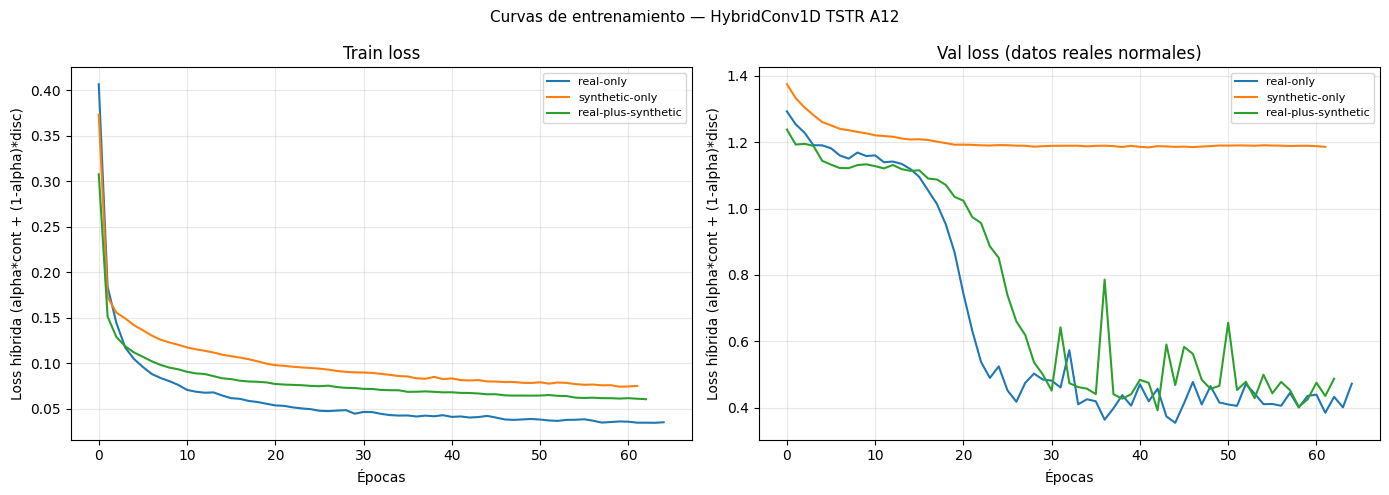

In [14]:
COLORS = {'real_only':'#1f77b4','synthetic_only':'#ff7f0e','real_plus_synthetic':'#2ca02c'}

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for sc, hist in histories.items():
    axes[0].plot(hist['train_loss'], color=COLORS[sc], label=sc.replace('_','-'), lw=1.5)
    axes[1].plot(hist['val_loss'],   color=COLORS[sc], label=sc.replace('_','-'), lw=1.5)
for ax, t in zip(axes, ['Train loss', 'Val loss (datos reales normales)']):
    ax.set_title(t); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_xlabel('Épocas'); ax.set_ylabel('Loss híbrida (alpha*cont + (1-alpha)*disc)')
plt.suptitle('Curvas de entrenamiento — HybridConv1D TSTR A12', fontsize=11)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()


C:\Users\j.manriquec\AppData\Local\Temp\1\ipykernel_3156\2728499922.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([all_errors[sc]['val'] for sc in SCENARIOS],


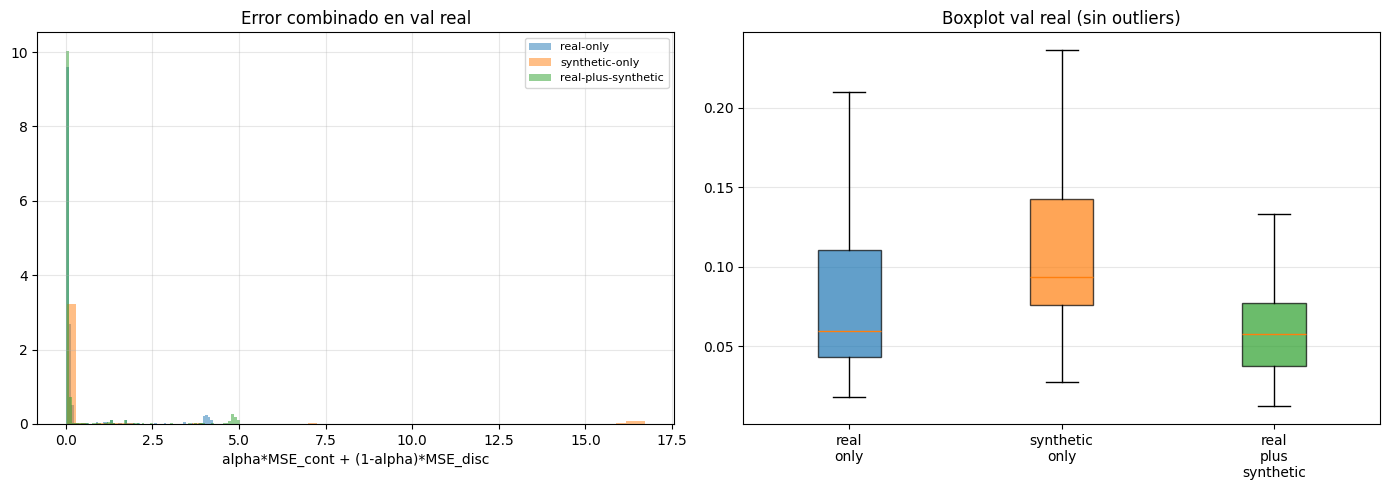

In [15]:
# Distribuciones de errores en val (solo datos reales)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for sc in SCENARIOS:
    axes[0].hist(all_errors[sc]['val'], bins=60, alpha=0.5, density=True,
                 color=COLORS[sc], label=sc.replace('_','-'))
axes[0].set_title('Error combinado en val real')
axes[0].set_xlabel('alpha*MSE_cont + (1-alpha)*MSE_disc'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

bp2 = axes[1].boxplot([all_errors[sc]['val'] for sc in SCENARIOS],
                      labels=[s.replace('_','\n') for s in SCENARIOS],
                      patch_artist=True, showfliers=False)
for patch, sc in zip(bp2['boxes'], SCENARIOS): patch.set_facecolor(COLORS[sc]); patch.set_alpha(0.7)
axes[1].set_title('Boxplot val real (sin outliers)'); axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'error_distributions.png'), dpi=120, bbox_inches='tight')
plt.show()


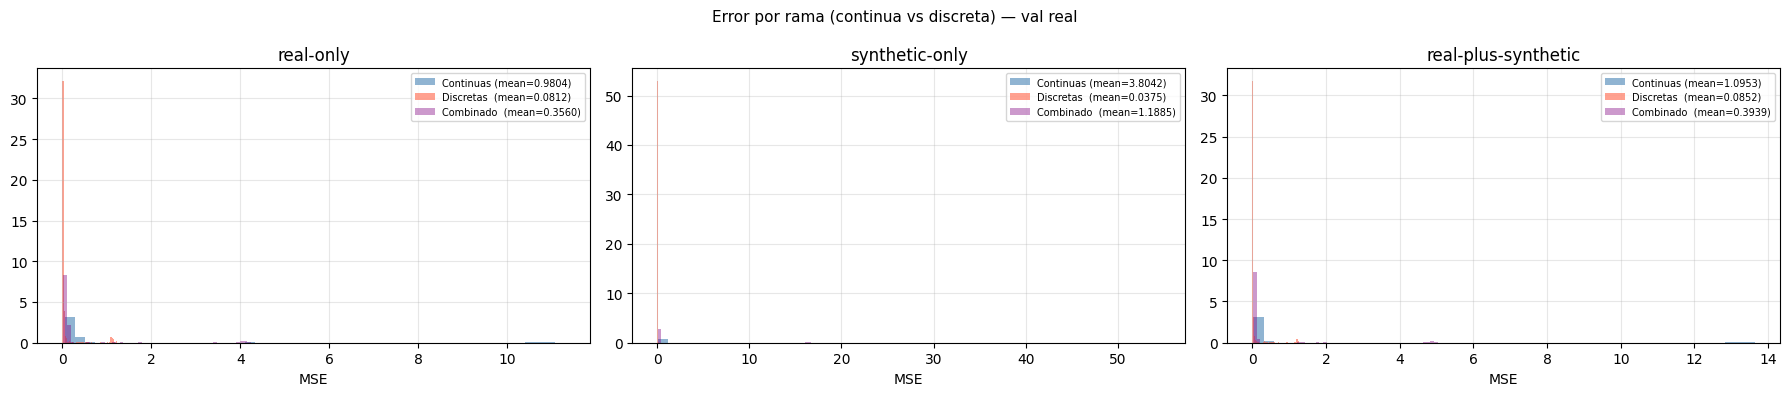

In [16]:
# Comparar error continuo vs discreto por escenario
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, sc in zip(axes, SCENARIOS):
    e_c = all_errors[sc]['val_c']
    e_d = all_errors[sc]['val_d']
    e_comb = all_errors[sc]['val']
    ax.hist(e_c,    bins=50, alpha=0.6, density=True, color='steelblue', label=f'Continuas (mean={e_c.mean():.4f})')
    ax.hist(e_d,    bins=50, alpha=0.6, density=True, color='tomato',    label=f'Discretas  (mean={e_d.mean():.4f})')
    ax.hist(e_comb, bins=50, alpha=0.4, density=True, color='purple',    label=f'Combinado  (mean={e_comb.mean():.4f})', linestyle='--')
    ax.set_title(sc.replace('_','-')); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xlabel('MSE')
plt.suptitle('Error por rama (continua vs discreta) — val real', fontsize=11)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'error_by_branch.png'), dpi=120, bbox_inches='tight')
plt.show()


In [17]:
# Tabla de umbrales por escenario
tau_rows = []
for sc in SCENARIOS:
    for p in [90, 95, 97.5, 99, 99.5]:
        tau_rows.append({'scenario': sc, 'percentil': p,
                         'tau': float(np.percentile(all_errors[sc]['val'], p))})
tau_df = pd.DataFrame(tau_rows)
pivot  = tau_df.pivot(index='percentil', columns='scenario', values='tau')[SCENARIOS]
print('Umbrales tau por escenario (sobre val real normal):')
display(pivot)


Umbrales tau por escenario (sobre val real normal):


scenario,real_only,synthetic_only,real_plus_synthetic
percentil,,,
90.0,0.285901,0.325545,0.261659
95.0,3.964025,16.125305,4.722025
97.5,4.075316,16.394838,4.850801
99.0,4.153989,16.625372,4.938267
99.5,4.177723,16.676720,4.970277


## 11. Guardar todos los artefactos

In [18]:
# Artefactos globales
summary_df.to_csv(RESULTS_DIR / 'summary_errors.csv', index=False)
joblib.dump(scaler_cont, RESULTS_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max,    RESULTS_DIR / 'disc_max.pkl')

with open(RESULTS_DIR / 'columns_config.json', 'w') as f:
    json.dump({'continuous_cols': continuous_cols, 'discrete_cols': discrete_cols,
               'feature_cols': feature_cols}, f, indent=4)

with open(RESULTS_DIR / 'config.json', 'w') as f:
    json.dump({
        'scenarios': SCENARIOS, 'window_size': WINDOW_SIZE, 'stride': STRIDE,
        'alpha': ALPHA, 'epochs_max': EPOCHS,
        'model_class': 'HybridConv1DAutoencoder',  # <-- distinto a la versión anterior
        'model_params': {k: (float(v) if isinstance(v,float) else v) for k,v in bp.items()},
        'n_train_real': int(len(X_tr_c)), 'n_synth_used': int(len(X_sy_c_used)),
        'n_val': int(len(X_va_c)), 'n_test': int(len(X_te_c)),
        'cont_channels': int(X_tr_c.shape[1]), 'disc_dim': int(X_tr_d.shape[1]),
        'dataset': 'SWaT A12 Mar 2026', 'timegan_dir': str(TIMEGAN_DIR),
    }, f, indent=4)

# Artefactos por escenario
for scenario in SCENARIOS:
    sc_dir = MODELS_DIR / scenario
    sc_dir.mkdir(parents=True, exist_ok=True)

    torch.save(models_tstr[scenario].state_dict(), sc_dir / 'model_state.pt')
    pd.DataFrame(histories[scenario]).to_csv(sc_dir / 'train_history.csv', index=False)
    np.save(sc_dir / 'val_errors.npy',   all_errors[scenario]['val'])
    np.save(sc_dir / 'val_errors_c.npy', all_errors[scenario]['val_c'])
    np.save(sc_dir / 'val_errors_d.npy', all_errors[scenario]['val_d'])
    np.save(sc_dir / 'test_errors.npy',  all_errors[scenario]['test'])

    tau_dict = {f'p{str(p).replace(".","_")}': float(np.percentile(all_errors[scenario]['val'], p))
                for p in [90, 95, 97.5, 99, 99.5]}
    with open(sc_dir / 'tau_dict.json', 'w') as f:
        json.dump(tau_dict, f, indent=4)

    with open(sc_dir / 'config.json', 'w') as f:
        json.dump({
            'scenario': scenario, 'model_class': 'HybridConv1DAutoencoder',
            'cont_channels': int(X_tr_c.shape[1]), 'disc_dim': int(X_tr_d.shape[1]),
            'seq_len': WINDOW_SIZE, 'window_size': WINDOW_SIZE, 'stride': STRIDE,
            'alpha': ALPHA,
            'epochs_run': len(histories[scenario]['train_loss']),
            'best_val_loss': float(min(histories[scenario]['val_loss'])),
            'val_error_mean': float(np.mean(all_errors[scenario]['val'])),
            'val_error_p95':  float(np.percentile(all_errors[scenario]['val'], 95)),
            'val_error_p99':  float(np.percentile(all_errors[scenario]['val'], 99)),
            'tau_dict': tau_dict,
            'continuous_cols': continuous_cols, 'discrete_cols': discrete_cols,
            'feature_cols': feature_cols,
            'train_shape_c': list(SCENARIOS_DATA[scenario][0].shape),
            'train_shape_d': list(SCENARIOS_DATA[scenario][1].shape),
        }, f, indent=4)

print('Artefactos guardados:')
print('RESULTS_DIR:', RESULTS_DIR)
for fp in sorted(RESULTS_DIR.iterdir()): print(f'  {fp.name}')
print()
print('MODELS_DIR:', MODELS_DIR)
for sc_dir in sorted(MODELS_DIR.iterdir()):
    print(f'  {sc_dir.name}/  -> {[f.name for f in sorted(sc_dir.iterdir())]}')


Artefactos guardados:
RESULTS_DIR: c:\Users\j.manriquec\ics-synthetic-data-augmentation\artifacts\tstr_internal_validation_a12
  columns_config.json
  config.json
  disc_max.pkl
  error_by_branch.png
  error_distributions.png
  scaler_cont.pkl
  summary_errors.csv
  training_curves.png

MODELS_DIR: c:\Users\j.manriquec\ics-synthetic-data-augmentation\models\detectors\conv1d_tstr_internal_a12
  real_only/  -> ['config.json', 'far_table.csv', 'model_state.pt', 'tau_dict.json', 'test_errors.npy', 'train_errors.npy', 'train_history.csv', 'val_errors.npy', 'val_errors_c.npy', 'val_errors_d.npy']
  real_plus_synthetic/  -> ['config.json', 'far_table.csv', 'model_state.pt', 'tau_dict.json', 'test_errors.npy', 'train_errors.npy', 'train_history.csv', 'val_errors.npy', 'val_errors_c.npy', 'val_errors_d.npy']
  synthetic_only/  -> ['config.json', 'far_table.csv', 'model_state.pt', 'tau_dict.json', 'test_errors.npy', 'train_errors.npy', 'train_history.csv', 'val_errors.npy', 'val_errors_c.npy', '

## 12. Interpretación de resultados

### Qué mide esta validación

Esta validación es **interna y no supervisada** — no hay etiquetas de ataque.
Lo que se mide es la calidad de la representación de normalidad de cada modelo:

- **val_error_mean menor** en `real_plus_synthetic` vs `real_only`: la augmentación
  mejoró la representación de normalidad.
- **val_error_std menor**: distribución de errores más compacta → umbrales de
  detección más precisos. Esto es especialmente importante para la cola alta
  (p95, p99) que es donde caen los ataques en la validación externa.
- **synthetic_only con error alto**: esperado y positivo — confirma que los
  sintéticos son distribuciones distintas a los reales (diversidad del TimeGAN).

### Diferencia respecto a la versión anterior del TSTR

El `HybridConv1DAutoencoder` procesa las ramas correctamente:
- **Rama continua (Conv1D)**: extrae patrones temporales en LIT101, AIT201, etc.
- **Rama discreta (MLP)**: procesa estadísticos de resumen sin asumir temporalidad

La `hybrid_loss` con `alpha=0.306` es idéntica a la de 01b — el modelo juzga
la reconstrucción de las discretas con más peso (69%) que las continuas (31%),
lo que está justificado porque generan 124 features de resumen vs 31 continuas.

### Próximo paso: validación externa (notebook 07)

Con estos modelos guardados en `conv1d_tstr_internal_a12/`, el notebook 07
evaluará la detección de ataques reales usando ROC-AUC, F1 y Recall — las
métricas supervisadas definitivas para la hipótesis de la tesis.
